## Step 1 — Install Dependencies

In [54]:
!pip install spacy transformers torch pandas -q
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.6/12.8 MB 7.6 MB/s eta 0:00:02
     --------- ------------------------------ 3.1/12.8 MB 7.4 MB/s eta 0:00:02
     ------------- -------------------------- 4.5/12.8 MB 7.4 MB/s eta 0:00:02
     ------------------ --------------------- 6.0/12.8 MB 7.4 MB/s eta 0:00:01
     ---------------------- ----------------- 7.1/12.8 MB 6.9 MB/s eta 0:00:01
     ----------------------- ---------------- 7.6/12.8 MB 6.3 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 6.2 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 6.2 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 6.2 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 3.8 MB/s eta 0:00:02
     --------------------------- ------------ 8.9/12.8 MB 3.8 MB/s eta 0:00:02
     ----------------------------- ---------- 9.4/12.8 MB 3

## Step 2 — Import Libraries

In [56]:
import pandas as pd
import spacy
from transformers import pipeline
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load('en_core_web_sm')
print(' spaCy loaded')

# Load HuggingFace sentiment model
print('⏳ Loading sentiment model (first time may take ~1 min)...')
sentiment_model = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512
)
print('Sentiment model loaded')

 spaCy loaded
⏳ Loading sentiment model (first time may take ~1 min)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment model loaded


## Step 3 — Load Dataset

In [58]:
import os

CSV_PATH = 'crimereport.csv'

if os.path.exists(CSV_PATH):
    df_raw = pd.read_csv(CSV_PATH)
    print(f'Loaded dataset: {df_raw.shape}')
    print(f'Columns: {list(df_raw.columns)}')
    df_raw.head(3)
else:
    print('crimereport.csv not found — using built-in sample data instead.')
    df_raw = pd.DataFrame(sample_data)
    print(f' Sample dataset created: {df_raw.shape}')

df_raw.head()

Loaded dataset: (115, 12)
Columns: ['id', 'created_at', 'text', 'location_name', 'country', 'place_type', 'username', 'name', 'user_location', 'retweet_count', 'favorite_count', 'lang']


,id,created_at,text,location_name,country,place_type,username,name,user_location,retweet_count,favorite_count,lang
0,429129916446031872,Fri Jan 31 05:51:59 +0000 2014,Active crime scene on I-59/20 near Jeff/Tusc C...,"Hoover, AL",United States,city,spann,James Spann,Alabama,66.0,4.0,en
1,429117247307923456,Fri Jan 31 05:01:39 +0000 2014,Police have arrested a suspect in the Monday s...,NaN,NaN,NaN,telegramreports,Rocky Mount Telegram,"Rocky Mount, N.C.",49.0,6.0,en
2,429315798893461505,Fri Jan 31 18:10:37 +0000 2014,Lawsuit alleges Chicago Police strip-searched ...,NaN,NaN,NaN,RaniaKhalek,Rania Khalek,Northern Virginia,20.0,6.0,en
3,429079910091476992,Fri Jan 31 02:33:17 +0000 2014,New NRA Advice: Don't Cooperate With Police If...,NaN,NaN,NaN,EricBoehlert,Eric Boehlert,NaN,19.0,3.0,en
4,429030956888899584,Thu Jan 30 23:18:45 +0000 2014,"Police failing to stamp out ‘honour crimes’, f...",NaN,NaN,NaN,thetimes,The Times of London,London,21.0,3.0,en


## Step 4 — Identify Text Column

In [60]:
# Auto-detect which column has the main text
text_col = None
for col in ['description', 'text', 'report', 'content', 'details', 'narrative']:
    if col in df_raw.columns:
        text_col = col
        break

# Fallback: use first string column
if text_col is None:
    for col in df_raw.columns:
        if df_raw[col].dtype == object:
            text_col = col
            break

print(f'Using text column: "{text_col}"')

# Limit to 20 rows for speed
df_work = df_raw[[text_col]].dropna().head(20).reset_index(drop=True)
print(f'   Processing {len(df_work)} records')

Using text column: "text"
   Processing 20 records


## Step 5 — Define Helper Functions

In [62]:
def classify_topic(text):
    """Rule-based topic classification from keywords."""
    t = text.lower()
    if any(w in t for w in ['fire', 'burn', 'smoke', 'arson', 'blaze']):
        return 'Fire'
    elif any(w in t for w in ['robbery', 'theft', 'stolen', 'burglar', 'steal', 'fraud', 'counterfeit']):
        return 'Theft / Robbery'
    elif any(w in t for w in ['accident', 'crash', 'collision', 'hit and run', 'vehicle']):
        return 'Traffic Accident'
    elif any(w in t for w in ['assault', 'attack', 'fight', 'shooting', 'shot', 'stab']):
        return 'Assault / Violence'
    elif any(w in t for w in ['drug', 'narcotic', 'possession', 'trafficking']):
        return 'Drug Offense'
    elif any(w in t for w in ['missing', 'disappeared', 'last seen']):
        return 'Missing Person'
    elif any(w in t for w in ['disturbance', 'noise', 'trespass', 'vandalism', 'graffiti']):
        return 'Public Disturbance'
    else:
        return 'General Incident'


def extract_entities(text):
    """Extract named entities using spaCy."""
    doc = nlp(text[:1000])  # cap length
    people    = [ent.text for ent in doc.ents if ent.label_ == 'PERSON']
    locations = [ent.text for ent in doc.ents if ent.label_ in ['GPE', 'LOC', 'FAC']]
    orgs      = [ent.text for ent in doc.ents if ent.label_ == 'ORG']
    dates     = [ent.text for ent in doc.ents if ent.label_ == 'DATE']
    return people, locations, orgs, dates


def get_severity(topic, sentiment):
    """Assign severity based on topic and sentiment."""
    high_topics = ['Assault / Violence', 'Fire', 'Missing Person']
    med_topics  = ['Theft / Robbery', 'Traffic Accident', 'Drug Offense']
    if topic in high_topics or sentiment == 'NEGATIVE':
        return 'High'
    elif topic in med_topics:
        return 'Medium'
    else:
        return 'Low'


print('Helper functions defined')

Helper functions defined


## Step 6 — Run NLP Pipeline on All Records

In [64]:
results = []
total = len(df_work)

for i, row in df_work.iterrows():
    text = str(row[text_col])

    # Sentiment
    sentiment_result = sentiment_model(text[:512])[0]
    sentiment_label  = sentiment_result['label']       # POSITIVE / NEGATIVE
    sentiment_score  = round(sentiment_result['score'], 3)

    # NER
    people, locations, orgs, dates = extract_entities(text)

    # Topic
    topic = classify_topic(text)

    # Severity
    severity = get_severity(topic, sentiment_label)

    results.append({
        'Text_ID':         f'TXT_{i+1:03d}',
        'Source':          'CrimeReport Dataset',
        'Raw_Text':        text[:200],
        'Sentiment':       sentiment_label,
        'Sentiment_Score': sentiment_score,
        'Entities_People':    ', '.join(people)    if people    else 'None',
        'Entities_Locations': ', '.join(locations) if locations else 'None',
        'Entities_Orgs':      ', '.join(orgs)      if orgs      else 'None',
        'Topic':           topic,
        'Severity':        severity
    })

    if (i + 1) % 5 == 0:
        print(f'   Processed {i+1}/{total}...')

df_text = pd.DataFrame(results)
print(f'\nDone! Processed {len(df_text)} records.')
df_text.head()

   Processed 5/20...
   Processed 10/20...
   Processed 15/20...
   Processed 20/20...

Done! Processed 20 records.


,Text_ID,Source,Raw_Text,Sentiment,Sentiment_Score,Entities_People,Entities_Locations,Entities_Orgs,Topic,Severity
0,TXT_001,CrimeReport Dataset,Active crime scene on I-59/20 near Jeff/Tusc C...,NEGATIVE,0.990,None,None,None,Assault / Violence,High
1,TXT_002,CrimeReport Dataset,Police have arrested a suspect in the Monday s...,NEGATIVE,0.978,None,None,Word Tabernacle Church,Assault / Violence,High
2,TXT_003,CrimeReport Dataset,Lawsuit alleges Chicago Police strip-searched ...,NEGATIVE,0.997,None,Chicago,None,General Incident,High
3,TXT_004,CrimeReport Dataset,New NRA Advice: Don't Cooperate With Police If...,NEGATIVE,0.998,None,None,New NRA Advice,General Incident,High
4,TXT_005,CrimeReport Dataset,"Police failing to stamp out ‘honour crimes’, f...",NEGATIVE,0.985,None,None,FGM,General Incident,High


## Step 7 — Save Output CSV

In [66]:
df_text.to_csv('text_output.csv', index=False)
print('Saved: text_output.csv')
print(f'   Shape: {df_text.shape}')
df_text

Saved: text_output.csv
   Shape: (20, 10)


,Text_ID,Source,Raw_Text,Sentiment,Sentiment_Score,Entities_People,Entities_Locations,Entities_Orgs,Topic,Severity
0,TXT_001,CrimeReport Dataset,Active crime scene on I-59/20 near Jeff/Tusc C...,NEGATIVE,0.990,None,None,None,Assault / Violence,High
1,TXT_002,CrimeReport Dataset,Police have arrested a suspect in the Monday s...,NEGATIVE,0.978,None,None,Word Tabernacle Church,Assault / Violence,High
2,TXT_003,CrimeReport Dataset,Lawsuit alleges Chicago Police strip-searched ...,NEGATIVE,0.997,None,Chicago,None,General Incident,High
3,TXT_004,CrimeReport Dataset,New NRA Advice: Don't Cooperate With Police If...,NEGATIVE,0.998,None,None,New NRA Advice,General Incident,High
4,TXT_005,CrimeReport Dataset,"Police failing to stamp out ‘honour crimes’, f...",NEGATIVE,0.985,None,None,FGM,General Incident,High
5,TXT_006,CrimeReport Dataset,Today's front page: \nPolice failing to stamp ...,NEGATIVE,0.997,None,None,None,General Incident,High
6,TXT_007,CrimeReport Dataset,Town of Tonawanda Police Search for Bank Robbe...,NEGATIVE,0.995,None,None,Town of Tonawanda Police Search for Bank Robbe...,Theft / Robbery,High
7,TXT_008,CrimeReport Dataset,"Due to lack of police protection, #Christians ...",NEGATIVE,0.996,None,Pakistan,None,General Incident,High
8,TXT_009,CrimeReport Dataset,New #NRA Advice: Don't Cooperate With Police I...,NEGATIVE,0.998,None,None,Crime Scene,General Incident,High
9,TXT_010,CrimeReport Dataset,Commish Batts makes a strong case for legalizi...,POSITIVE,0.988,"Commish Batts, @baltimoresun http://t.co/A0TRU...",Baltimore,None,General Incident,Low


## Step 8 — Visualizations

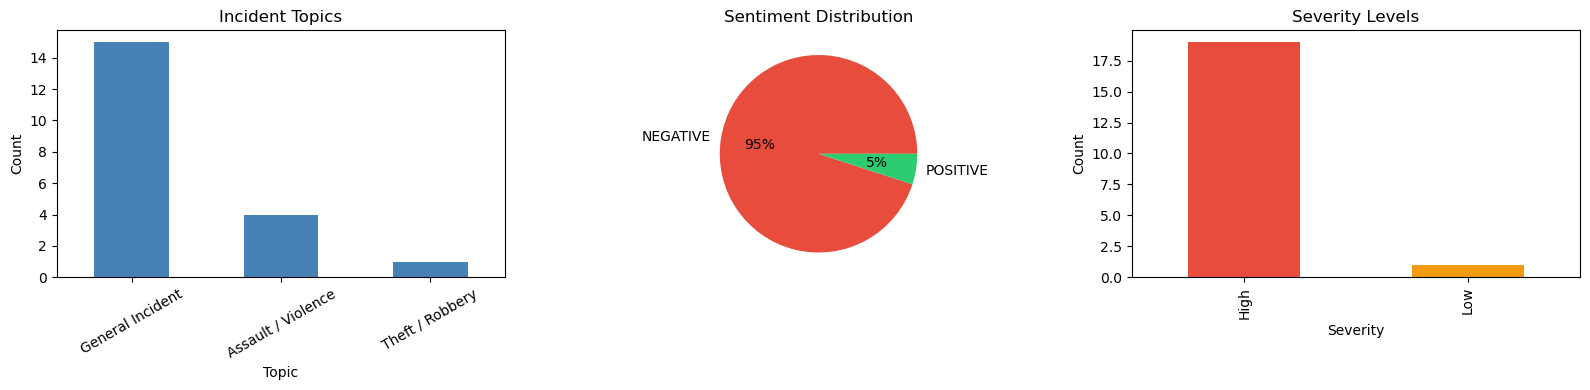

 Charts saved: text_charts.png


In [68]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Topic distribution
df_text['Topic'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Incident Topics')
axes[0].set_xlabel('Topic')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Sentiment distribution
df_text['Sentiment'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.0f%%',
    colors=['#e74c3c', '#2ecc71']
)
axes[1].set_title('Sentiment Distribution')
axes[1].set_ylabel('')

# Severity distribution
df_text['Severity'].value_counts().plot(
    kind='bar', ax=axes[2],
    color=['#e74c3c', '#f39c12', '#2ecc71']
)
axes[2].set_title('Severity Levels')
axes[2].set_xlabel('Severity')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('text_charts.png', dpi=150)
plt.show()
print(' Charts saved: text_charts.png')

## Step 9 — Summary Statistics

In [70]:
print('=== Text Modality Summary ===')
print(f'Total records processed : {len(df_text)}')
print(f'Unique topics found     : {df_text["Topic"].nunique()}')
print(f'Negative sentiment      : {(df_text["Sentiment"] == "NEGATIVE").sum()}')
print(f'Positive sentiment      : {(df_text["Sentiment"] == "POSITIVE").sum()}')
print(f'High severity incidents : {(df_text["Severity"] == "High").sum()}')
print(f'Medium severity         : {(df_text["Severity"] == "Medium").sum()}')
print(f'Low severity            : {(df_text["Severity"] == "Low").sum()}')
print()
print('Topic breakdown:')
print(df_text['Topic'].value_counts().to_string())

=== Text Modality Summary ===
Total records processed : 20
Unique topics found     : 3
Negative sentiment      : 19
Positive sentiment      : 1
High severity incidents : 19
Medium severity         : 0
Low severity            : 1

Topic breakdown:
Topic
General Incident      15
Assault / Violence     4
Theft / Robbery        1
